In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import contextily as ctx

import warnings
warnings.filterwarnings('ignore')

data_dir = '/Users/jcolen/Documents/chkd_toy_problem/data'

In [2]:
smoke_alerts = gpd.read_file(f'{data_dir}/combined_smoke_alerts/combined_smoke_alerts.shp')
print(smoke_alerts.crs)
smoke_alerts['date_local'] = pd.to_datetime(smoke_alerts['date_local'])
smoke_alerts['date_local'] = smoke_alerts['date_local'].dt.to_period('D')
smoke_alerts = smoke_alerts.set_index('date_local')

# Assign categorical column value to Density
density_dtype = pd.api.types.CategoricalDtype(categories=['None', 'Light', 'Medium', 'Heavy'], ordered=True)
smoke_alerts['Density'] = smoke_alerts['Density'].astype(density_dtype)

smoke_alerts

EPSG:4269


,Density,geometry
date_local,,
2018-05-01,Light,"MULTIPOLYGON (((-77.10177 36.54457, -77.10303 ..."
2018-05-01,None,"POLYGON ((-76.91572 36.55209, -76.91587 36.552..."
2018-05-02,Light,"MULTIPOLYGON (((-76.77884 36.82046, -76.41165 ..."
2018-05-02,None,"MULTIPOLYGON (((-77.12286 36.54411, -77.12299 ..."
2018-05-03,None,"POLYGON ((-76.91556 36.55209, -76.91572 36.552..."
...,...,...
2023-08-26,Light,"MULTIPOLYGON (((-77.09568 37.16224, -77.0939 3..."
2023-08-27,Light,"POLYGON ((-76.91587 36.55209, -76.9159 36.5520..."
2023-08-28,Light,"POLYGON ((-76.91572 36.55209, -76.91587 36.552..."


(-77.7, -75.7, 36.55, 37.65)

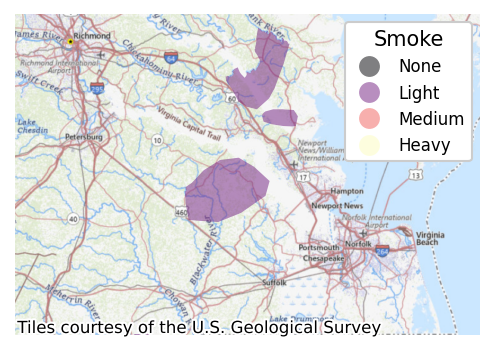

In [23]:
# Plot geographic region for a random day
date = '2023-05-31'
date = '2018-05-01'
date_alerts = smoke_alerts.loc[[date]]

fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=150)
date_alerts[date_alerts['Density'] != 'None'].plot('Density', ax=ax, legend=True, alpha=0.5, cmap='magma',
                  legend_kwds=dict(
                loc='upper right',
                title=f'Smoke',
                ncol=1,
                framealpha=1,
                fontsize=8
                  ))
ax.set(xlim=[-77.7, -75.7], ylim=[36.4, 37.65])
ctx.add_basemap(ax, source=ctx.providers.USGS.USTopo, crs=date_alerts.crs)
ax.set(xlim=[-77.7, -75.7], ylim=[36.55, 37.65])
ax.axis('off')

,Density,geometry
date_local,,
2018-05-01,Light,"MULTIPOLYGON (((-77.10177 36.54457, -77.10303 ..."
2018-05-01,None,"POLYGON ((-76.91572 36.55209, -76.91587 36.552..."


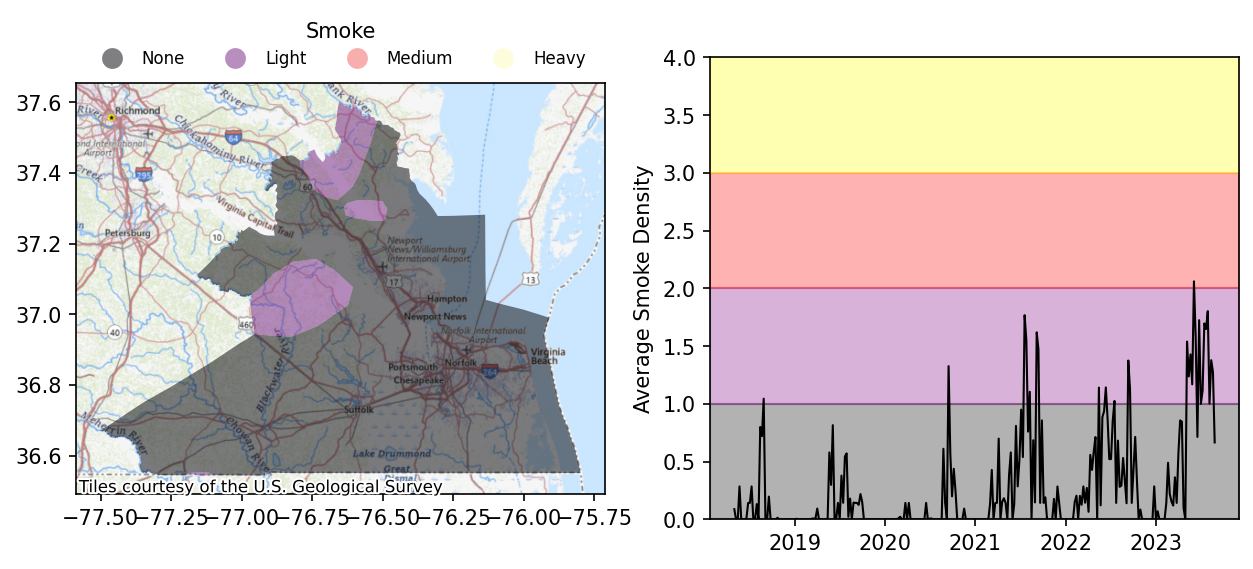

In [21]:
# Plot geographic region for a random day
date = '2023-05-31'
date = '2018-05-01'
date_alerts = smoke_alerts.loc[[date]]

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)
date_alerts.plot('Density', ax=ax[0], legend=True, alpha=0.5, cmap='magma',
                  legend_kwds=dict(
                      loc='lower center',
                      title=f'Smoke',
                      bbox_to_anchor=(0.5, 1),
                      ncol=4,
                      framealpha=0,
                      fontsize=8
                  ))
ctx.add_basemap(ax[0], source=ctx.providers.USGS.USTopo, crs=date_alerts.crs)


#Get regional average density for each week
week_alerts = smoke_alerts.copy()
week_alerts.index = week_alerts.index.to_timestamp().to_period('W')
week_alerts['area'] = week_alerts['geometry'].area
average_smoke = week_alerts.groupby('date_local').apply(lambda x: pd.Series({'Smoke density': x['Density'].cat.codes.dot(x['area']) / x['area'].sum()}))

ax[1].plot(average_smoke.index.to_timestamp(), average_smoke['Smoke density'], color='black', linewidth=1)
xlim = ax[1].get_xlim()
ax[1].fill_between(xlim, 0, 1, color='black', alpha=0.3)
ax[1].fill_between(xlim, 1, 2, color='purple', alpha=0.3)
ax[1].fill_between(xlim, 2, 3, color='red', alpha=0.3)
ax[1].fill_between(xlim, 3, 4, color='yellow', alpha=0.3)

ax[1].set(xlim=xlim, ylim=[0,4], ylabel='Average Smoke Density')

date_alerts